In [3]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipykernel_1352/440907590.py:9: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [12]:
data = np.loadtxt(open('sample_data/mnist_train_small.csv', 'rb'), delimiter=',')

# don't need the lables
data = data[:,1:]

# normalize the data to a range of [0 1]
data_norm = data / np.max(data)

dataT = torch.tensor(data_norm, dtype=torch.float32)

## Creating the Autoencoder


In [ ]:
def createTheMNISTAE():
  class aenet(nn.Module):
    def __init__(self):
      super().__init__()

      # input layer
      self.input = nn.Linear(784, 250) # images are 28x28 pixels, so 784 inputs

      # encoder layer
      self.enc = nn.Linear(250, 50)

      # latent layer
      self.lat = nn.Linear(50, 250)

      # decoder layer
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu( self.input(x) )
      x = F.relu( self.enc(x) )
      x = F.relu( self.lat(x) )
      y = F.sigmoid( self.dec(x) ) # the data is normalized to [0 1] so we use a sigmoid activation function so our output is also in the range [0 1]
      return y

  
  net = aenet()

  # loss function
  lossfun = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

  return net, lossfun, optimizer

## Testing the model before training


In [ ]:
net, lossfun, optimizer = createTheMNISTAE()

X = dataT[:5,:] # getting the 5 rows

yHat = net(X) # forward pass

# these both should be the same shape, (5, 784), because we are passing in 5 rows of data and the output is also 784 pixels, and output is also the same shape as the input because we are trying to reconstruct the input
print(X.shape)
print(yHat.shape)

torch.Size([5, 784])
torch.Size([5, 784])


**_Visualizing the first forward passed results_**


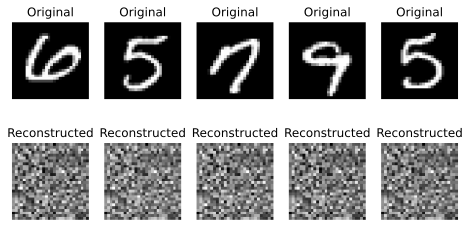

In [30]:
fix, axes = plt.subplots(2, 5, figsize=(8, 4))

for i in range(5):
  axes[0,i].imshow(X[i,:].detach().numpy().reshape(28,28), cmap='gray')
  axes[0,i].set_title('Original')
  axes[0,i].axis('off')

  axes[1,i].imshow(yHat[i,:].detach().numpy().reshape(28,28), cmap='gray')
  axes[1,i].set_title('Reconstructed')
  axes[1,i].axis('off')

plt.show()

## Training the model


In [43]:
def train_model():
  epochs = 10000

  net, lossfun, optimizer = createTheMNISTAE()

  losses = torch.zeros(epochs)

  for i in range(epochs):
    randomidx = np.random.choice(dataT.shape[0], size=32) # randomly select 32 rows of data

    X = dataT[randomidx,:]

    # forward pass
    yHat = net(X)

    # compute the loss
    loss = lossfun(yHat, X) # instead of y, we use X because we are trying to reconstruct the input
    losses[i] = loss

    # zero the gradients
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    # update the weights
    optimizer.step()

  return losses, net

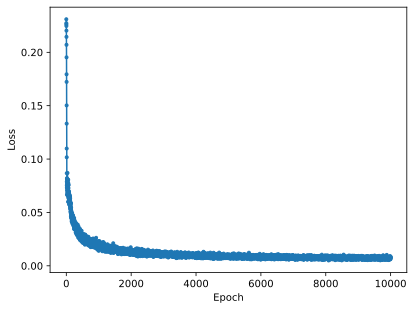

In [44]:
losses, net = train_model()

plt.plot(losses.detach().numpy(), '.-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

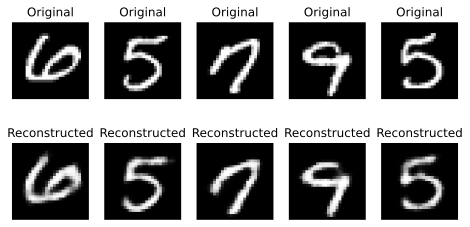

In [46]:
X = dataT[:5,:] # getting the 5 rows
yHat = net(X) # forward pass

fix, axes = plt.subplots(2, 5, figsize=(8, 4))

for i in range(5):
  axes[0,i].imshow(X[i,:].detach().numpy().reshape(28,28), cmap='gray')
  axes[0,i].set_title('Original')
  axes[0,i].axis('off')

  axes[1,i].imshow(yHat[i,:].detach().numpy().reshape(28,28), cmap='gray')
  axes[1,i].set_title('Reconstructed')
  axes[1,i].axis('off')

plt.show()

## Add noise then denoise using Autoencoder


**_We will pass through the previously trained autoencoder model_**


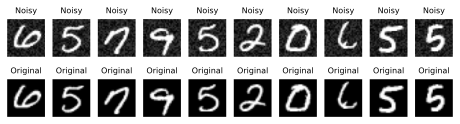

In [62]:
X = dataT[:10, :] # first 10 rows

# add noise
Xnoise = X + torch.rand_like(X)/4

Xnoise[Xnoise > 1] = 1 # clip the values to be in the range [0 1]

fig, axes = plt.subplots(2, 10, figsize=(8, 2))

for i in range(10):
  axes[0,i].imshow(Xnoise[i,:].detach().numpy().reshape(28,28), cmap='gray')
  axes[0,i].set_title('Noisy', fontsize=8)
  axes[0,i].axis('off')

  axes[1,i].imshow(X[i,:].detach().numpy().reshape(28,28), cmap='gray')
  axes[1,i].set_title('Original', fontsize=8)
  axes[1,i].axis('off')

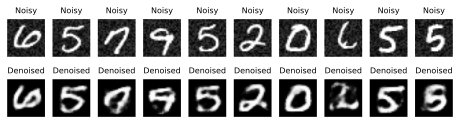

In [63]:
yHat = net(Xnoise) # forward pass

fig, axes = plt.subplots(2, 10, figsize=(8, 2))

for i in range(10):
  axes[0,i].imshow(Xnoise[i,:].detach().numpy().reshape(28,28), cmap='gray')
  axes[0,i].set_title('Noisy', fontsize=8)
  axes[0,i].axis('off')

  axes[1,i].imshow(yHat[i,:].detach().numpy().reshape(28,28), cmap='gray')
  axes[1,i].set_title('Denoised', fontsize=8)
  axes[1,i].axis('off')